# Tunable compliance — emergent grasps

## In-hand manipulation

The hand closes to a PC1 grasp and two asymmetric stiffness configurations are applied:
**Radial grasp** (Side B = index+middle at $K_\mathrm{high}$, Side A = pinky+ring at $K_\mathrm{low}$) and **Ulnar grasp** (sides swapped).
The thumb is held at $K_\mathrm{uniform}$ throughout both phases.
The spring length is the task-spring elongation $\|\Delta p\|$ from the PC1 reference fingertip position.

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys
from pathlib import Path

sys.path.insert(0, os.path.join('../../'))
from plot_config import draw_radar, COLORS, FIG_W_SINGLE, FIG_W_DOUBLE, set_font_size

from hand_config import (
    FINGERTIPS,
    SIDE_A_SOFT, SIDE_B_SOFT,
    K_UNIFORM, K_HIGH, K_LOW, THUMB_ASYM_RATIO,
    K_ROT, K_BACKGROUND_IH,
    K_BACKGROUND_DG, K_SOFT, K_STIFF,
    CONDITIONS,
)

FIG_W = 10   # inches — change freely
FIG_H = 6    # inches — change freely

GRID = False
FONT_SIZE = 18  # pt — change to rescale all text uniformly
set_font_size(FONT_SIZE)

PHASES       = ['uniform', 'asym_a', 'asym_b']
PHASE_LABELS = {'uniform': 'Uniform grasp', 'asym_a': 'Radial grasp', 'asym_b': 'Ulnar grasp'}
PHASE_COLORS = {'uniform': '#0072B2', 'asym_a': '#E69F00', 'asym_b': '#D55E00'}

SIDE_A = SIDE_A_SOFT   # ['pinky', 'ring']  — K_low in Radial grasp, K_high in Ulnar grasp
SIDE_B = SIDE_B_SOFT   # ['index', 'middle'] — K_high in Radial grasp, K_low in Ulnar grasp

OUTPUT_INHAND = os.path.join('outputs', 'inhand_manipulation')
os.makedirs(OUTPUT_INHAND, exist_ok=True)

def load_inhand():
    path = Path(OUTPUT_INHAND) / 'inhand_run.csv'
    return pd.read_csv(path) if path.exists() else None

df = load_inhand()
if df is None:
    print('No data — run inhand_manipulation.py first.')
else:
    print(df['phase'].value_counts().to_dict())

{'asym_b': 118, 'uniform': 117, 'asym_a': 117}


In [95]:
# ---- Radar plots: width + aspect ratio (shared by ALL radar charts) ----
RADAR_W      = 10 * 0.6
RADAR_ASPECT = 0.7
RADAR_FIGSIZE   = (RADAR_W, RADAR_W * RADAR_ASPECT)
RADAR_AXES_RECT = [0.12, 0.10, 0.50, 0.80]   # polar axes box; legend sits to its right
RADAR_LEG_BBOX  = (1.28, 0.5)                # legend anchor (axes coords), clears labels

In [96]:
# ---- Bar plots: width + aspect ratio (shared by ALL bar charts) ----
BAR_W      = 10 * 0.6
BAR_ASPECT = 0.7
BAR_FIGSIZE = (BAR_W, BAR_W * BAR_ASPECT)

### Tip stiffness $K_t$ per finger

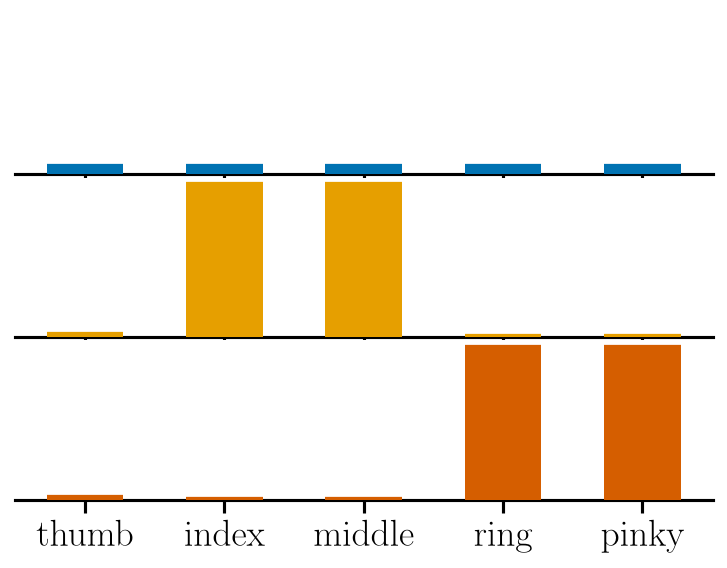

In [97]:
# ── Tunable layout ────────────────────────────────────────────────────────────
KT_FIG_W        = BAR_W       # figure width  [inches]
KT_ASPECT       = BAR_ASPECT  # height / width
KT_SUBPLOT_GAP  = 0.02        # gap between the 3 subplots [0 = touching, 1 = one subplot height apart]
KT_BAR_WIDTH    = 0.55        # bar width [fraction of x slot]
KT_BAR_SPACING  = 1.0         # centre-to-centre distance between adjacent bars [x units]
KT_CAP_LW       = 3.0         # linewidth of cap line at each bar top

_KT_CFG = {
    'uniform': {f: K_UNIFORM for f in FINGERTIPS},
    'asym_a':  {**{f: K_LOW if f in SIDE_A_SOFT else K_HIGH for f in FINGERTIPS},
                'thumb': K_UNIFORM / THUMB_ASYM_RATIO},
    'asym_b':  {**{f: K_LOW if f in SIDE_B_SOFT else K_HIGH for f in FINGERTIPS},
                'thumb': K_UNIFORM / THUMB_ASYM_RATIO},
}
_KT = (
    {phase: {f: float(df[df['phase'] == phase][f'k_{f}_Npm'].mean()) for f in FINGERTIPS}
     for phase in PHASES}
    if df is not None else _KT_CFG
)

fig, axes = plt.subplots(3, 1,
                          figsize=(KT_FIG_W, KT_FIG_W * KT_ASPECT),
                          sharex=True, sharey=True,
                          gridspec_kw={'hspace': KT_SUBPLOT_GAP})
x = np.arange(len(FINGERTIPS)) * KT_BAR_SPACING

for ax, phase in zip(axes, PHASES):
    vals = [_KT[phase][f] for f in FINGERTIPS]
    ax.bar(x, vals, KT_BAR_WIDTH, color=PHASE_COLORS[phase], zorder=2)
    for xi, v in zip(x, vals):
        ax.hlines(v, xi - KT_BAR_WIDTH / 2, xi + KT_BAR_WIDTH / 2,
                  colors=PHASE_COLORS[phase], linewidth=KT_CAP_LW, zorder=3)
    ax.yaxis.set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_zorder(0)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(FINGERTIPS)

fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_kt_per_finger.pdf'), bbox_inches='tight')
plt.show()

### Spring length per finger

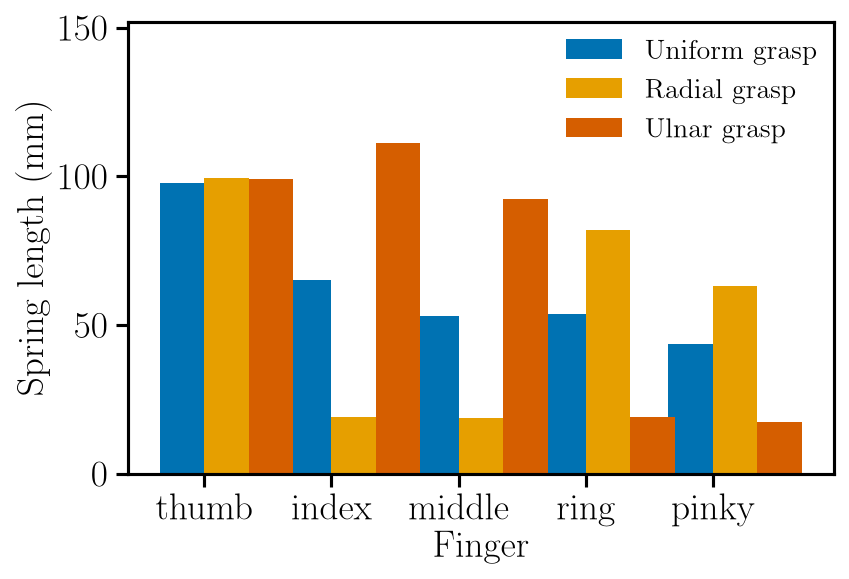

In [98]:
fig, ax = plt.subplots(figsize=BAR_FIGSIZE)
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
            stds.append(float(mag.std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Spring length (mm)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.30)   # room for the legend above the bars
ax.legend(loc='upper right', ncol=1, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_spring_length.pdf'), bbox_inches='tight')
plt.show()

Finger spring lengths (mm):


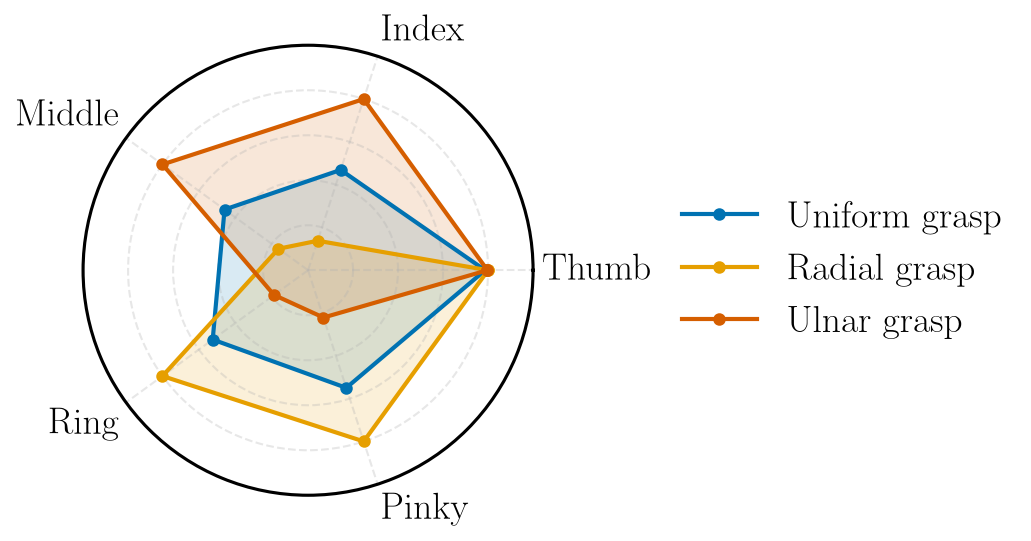

In [99]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        if df is not None:
            rows = df[df['phase'] == phase]
            mag  = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                           rows[f'disp_{f}_y_m']**2 +
                           rows[f'disp_{f}_z_m']**2) * 1e3
            means.append(float(mag.mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger spring lengths (mm):")
fig = plt.figure(figsize=RADAR_FIGSIZE)
_ax = fig.add_axes(RADAR_AXES_RECT, projection='polar')
draw_radar([f.capitalize() for f in FINGERTIPS], traces, ax=_ax)
_ax.legend(loc='center left', bbox_to_anchor=RADAR_LEG_BBOX,
           ncol=1, frameon=False,
           fontsize=plt.rcParams.get('axes.labelsize', 18))
fig.savefig(os.path.join(OUTPUT_INHAND, 'radar_spring_length.pdf'))
plt.show()

### Contact force magnitude per finger

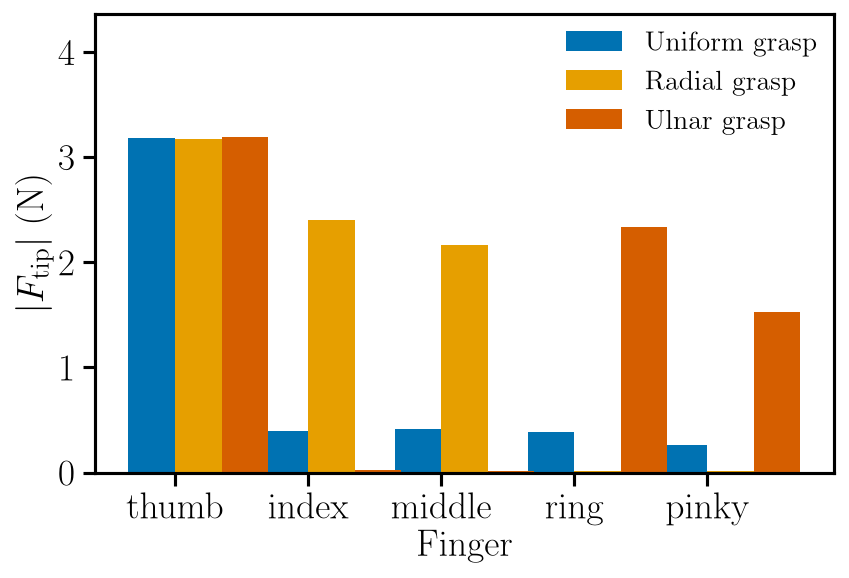

In [100]:
fig, ax = plt.subplots(figsize=BAR_FIGSIZE)
x = np.arange(len(FINGERTIPS))
width = 0.35

for i, phase in enumerate(PHASES):
    means, stds = [], []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
            stds.append(float(rows[col].std()))
        else:
            means.append(0.0); stds.append(0.0)
    ax.bar(x + i * width, means, width,
           label=PHASE_LABELS[phase], color=PHASE_COLORS[phase])

ax.set_xticks(x + width / 2)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ (N)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.30)   # room for the legend above the bars
ax.legend(loc='upper right', ncol=1, frameon=False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_force.pdf'), bbox_inches='tight')
plt.show()

Finger contact forces (N):


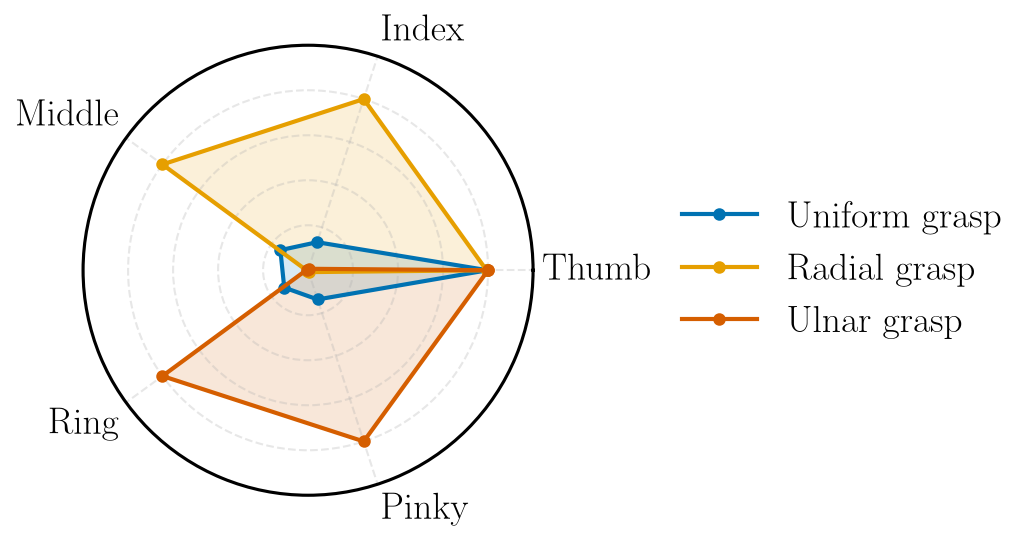

In [101]:
traces = []
for phase in PHASES:
    means = []
    for f in FINGERTIPS:
        col = f'force_1st_{f}_mag_N'
        if df is not None and col in df.columns:
            rows = df[df['phase'] == phase]
            means.append(float(rows[col].mean()))
        else:
            means.append(0.0)
    traces.append({'label': PHASE_LABELS[phase], 'values': means, 'color': PHASE_COLORS[phase]})

print("Finger contact forces (N):")
fig = plt.figure(figsize=RADAR_FIGSIZE)
_ax = fig.add_axes(RADAR_AXES_RECT, projection='polar')
draw_radar([f.capitalize() for f in FINGERTIPS], traces, ax=_ax)
_ax.legend(loc='center left', bbox_to_anchor=RADAR_LEG_BBOX,
           ncol=1, frameon=False,
           fontsize=plt.rcParams.get('axes.labelsize', 18))
fig.savefig(os.path.join(OUTPUT_INHAND, 'radar_force.pdf'))
plt.show()

### Final hand pose per phase

The motor configuration $q$ at the end of **Radial grasp** and **Ulnar grasp** rendered with `ModelIDHand.hand_viz`.

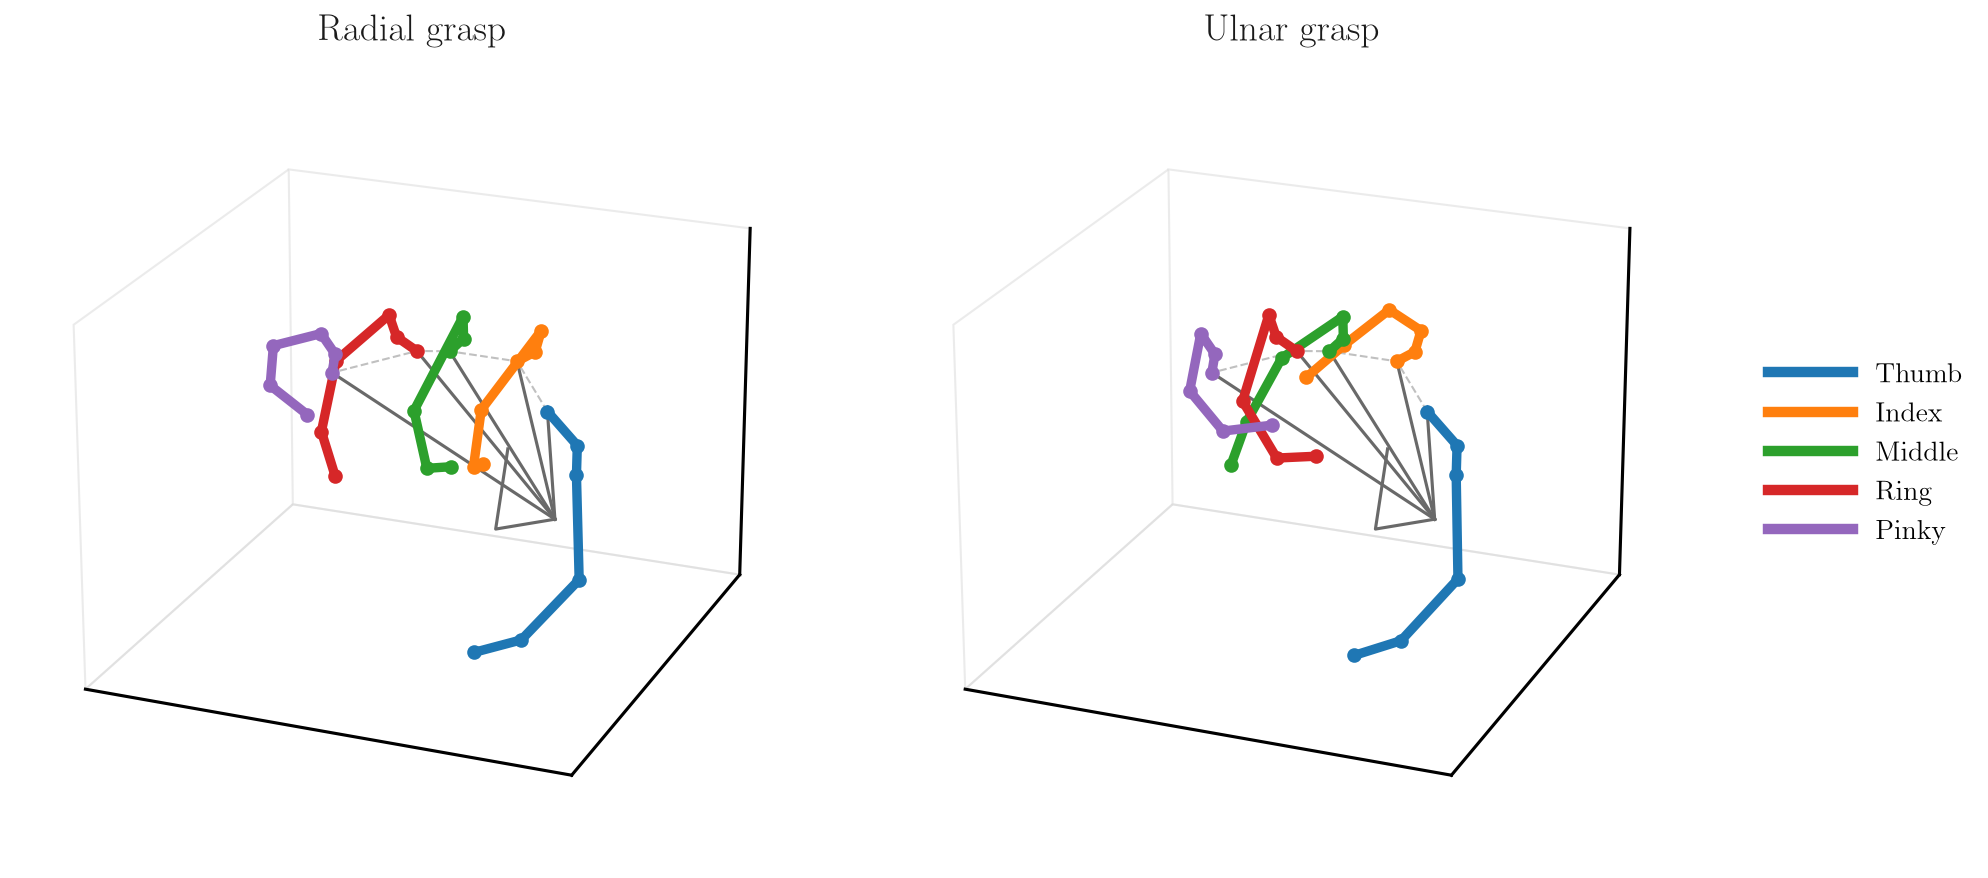

In [102]:
from ModelIDHand.hand_viz import plot_hand, _COL

_FIN_ALL = ['thumb', 'index', 'middle', 'ring', 'pinky']
_STYLE   = dict(linestyle='-', linewidth=4.5, marker='o', markersize=6.0)
_ELEV, _AZIM = 22, 112

INHAND_SNAP_PHASES = ['asym_a', 'asym_b']
INHAND_TITLES  = {'asym_a':  'Radial grasp',
                  'asym_b':  'Ulnar grasp'}

_Q_COLS = [f'q_motor_{i}_rad' for i in range(13)]


def _polish_ax(ax, title):
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(''); ax.set_ylabel(''); ax.set_zlabel('')
    for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
        pane.fill = False
        pane.set_edgecolor('#d8d8d8')
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis._axinfo['grid']['color']     = (0.88, 0.88, 0.88, 0.6)
        axis._axinfo['grid']['linewidth'] = 0.4
    ax.view_init(elev=_ELEV, azim=_AZIM)
    ax.set_title(title,
                 fontweight='semibold', pad=14, color='#1a1a1a')


def _sync_axes(axes):
    lims = np.array([[a.get_xlim3d(), a.get_ylim3d(), a.get_zlim3d()] for a in axes])
    xl = [lims[:, 0, 0].min(), lims[:, 0, 1].max()]
    yl = [lims[:, 1, 0].min(), lims[:, 1, 1].max()]
    zl = [lims[:, 2, 0].min(), lims[:, 2, 1].max()]
    span = max(xl[1] - xl[0], yl[1] - yl[0], zl[1] - zl[0])
    cx, cy, cz = 0.5 * sum(xl), 0.5 * sum(yl), 0.5 * sum(zl)
    for a in axes:
        a.set_xlim3d(cx - span / 2, cx + span / 2)
        a.set_ylim3d(cy - span / 2, cy + span / 2)
        a.set_zlim3d(cz - span / 2, cz + span / 2)


_LEG = [plt.Line2D([0], [0], color=_COL[n], lw=5.0, ls='-', label=n.capitalize())
        for n in _FIN_ALL]

if df is not None:
    fig = plt.figure(figsize=(12, 6))
    fig.patch.set_facecolor('white')
    axes = []
    for i, phase in enumerate(INHAND_SNAP_PHASES):
        rows = df[df['phase'] == phase]
        if rows.empty:
            continue
        q = rows[_Q_COLS].iloc[-1].to_numpy(dtype=np.float64)
        ax = fig.add_subplot(1, 2, i + 1, projection='3d')
        plot_hand(q, ax=ax, style=_STYLE)
        leg = ax.get_legend()
        if leg: leg.remove()
        _polish_ax(ax, INHAND_TITLES[phase])
        axes.append(ax)
    _sync_axes(axes)
    fig.legend(handles=_LEG, loc='center left', ncol=1,
               frameon=False,
               bbox_to_anchor=(1.0, 0.5), handlelength=3.0)
    fig.tight_layout()
    fig.savefig(os.path.join(OUTPUT_INHAND, 'inhand_hand_pose.pdf'),
                bbox_inches='tight', dpi=300)
    plt.show()

## Dynamic grasping

The UR5 slides the hand along +X. The hand closes to PC1 at a fixed distance under three stiffness schedules:
**Soft** ($K_\mathrm{soft}$ throughout), **Stiff** ($K_\mathrm{stiff}$ throughout),
**Adaptive** ($K_\mathrm{soft}$ at close, then ramps to $K_\mathrm{stiff}$).

In [103]:
OUTPUT_GRASP = os.path.join('outputs', 'dynamic_grasp')
os.makedirs(OUTPUT_GRASP, exist_ok=True)

# CONDITIONS imported from hand_config: ['soft', 'stiff', 'adaptive']
COND_LABELS   = {'soft': 'Soft', 'stiff': 'Stiff', 'adaptive': 'Adaptive'}
COND_COLORS   = {'soft': '#56B4E9', 'stiff': '#D55E00', 'adaptive': '#009E73'}


def load_dynamic(condition):
    path = Path(OUTPUT_GRASP) / f'dynamic_grasp_{condition}.csv'
    return pd.read_csv(path) if path.exists() else None


# Steady-state window: last 20 % of the post-close samples.
def _steady(df_dg):
    closed = df_dg[df_dg['phase'] != 'open']
    return closed.tail(max(1, len(closed) // 5)) if not closed.empty else closed


dfs_dg = {c: load_dynamic(c) for c in CONDITIONS}
print({c: (len(d) if d is not None else 0) for c, d in dfs_dg.items()})


def _steady_phase(df_dg, phase):
    rows = df_dg[df_dg['phase'] == phase]
    return rows.tail(max(1, len(rows) // 5)) if not rows.empty else rows


COND_PANELS = [
    {'cond': 'soft',     'label': 'Soft',              'color': COND_COLORS['soft'],
     'sel': _steady},
    {'cond': 'stiff',    'label': 'Stiff',             'color': COND_COLORS['stiff'],
     'sel': _steady},
    {'cond': 'adaptive', 'label': 'Adaptive (before)', 'color': '#66C2A5',
     'sel': lambda d: _steady_phase(d, 'soft')},
    {'cond': 'adaptive', 'label': 'Adaptive (after)',  'color': COND_COLORS['adaptive'],
     'sel': lambda d: _steady_phase(d, 'closed')},
]


# ── Bar-chart layout helpers ──────────────────────────────────────────────
from matplotlib.legend_handler import HandlerBase
import matplotlib.patches as _mpatch

class _SplitHandler(HandlerBase):
    """Legend handle that draws a split two-colour rectangle."""
    def create_artists(self, legend, orig_handle, xd, yd, w, h, fs, trans):
        c1, c2 = orig_handle
        r1 = _mpatch.Rectangle([xd,       yd], w / 2, h, fc=c1, ec='none', transform=trans)
        r2 = _mpatch.Rectangle([xd + w/2, yd], w / 2, h, fc=c2, ec='none', transform=trans)
        return [r1, r2]

_SLOT_W = 0.27   # distance between group centres
_BAR_W  = 0.23   # single-condition bar width
_SUB_W  = 0.115  # each adaptive sub-bar width (2 × _SUB_W = _BAR_W)
_ADAPT_BEFORE_COLOR = '#66C2A5'
_ADAPT_AFTER_COLOR  = COND_COLORS['adaptive']

def _dg_legend(ax):
    """Attach the 3-entry DG legend (Soft / Stiff / Adaptive split patch)."""
    handles = [
        _mpatch.Patch(color=COND_COLORS['soft'],  label='Soft'),
        _mpatch.Patch(color=COND_COLORS['stiff'], label='Stiff'),
        (_ADAPT_BEFORE_COLOR, _ADAPT_AFTER_COLOR),
    ]
    labels = ['Soft', 'Stiff', 'Adaptive']
    ax.legend(handles, labels,
              handler_map={tuple: _SplitHandler()},
              loc='upper center',
              ncol=3, frameon=False)

{'soft': 215, 'stiff': 215, 'adaptive': 215}


### Spring length per finger

Task-spring elongation $\|\Delta p\|$ averaged over the last 20 % of the post-close samples (steady-state).

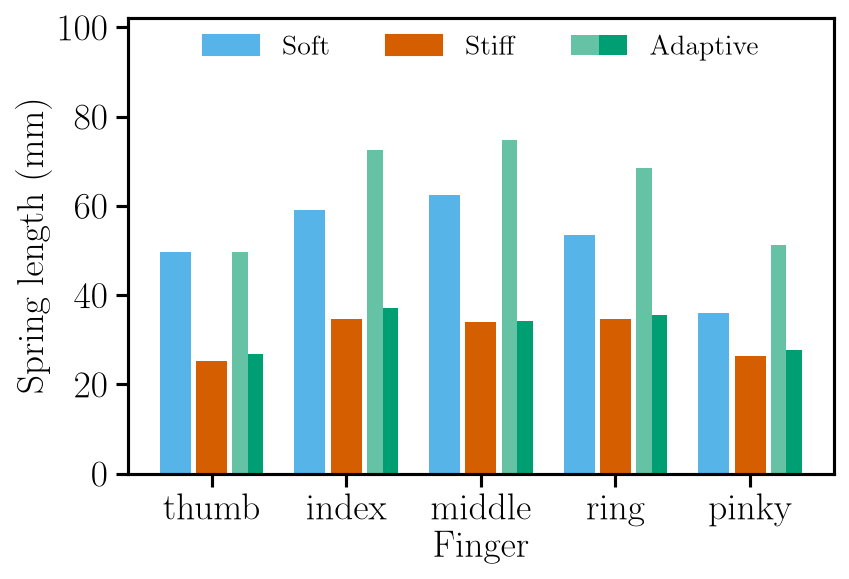

In [104]:
fig, ax = plt.subplots(figsize=BAR_FIGSIZE)
x = np.arange(len(FINGERTIPS))

for i, panel in enumerate(COND_PANELS):
    df_dg = dfs_dg.get(panel['cond'])
    means, stds = [], []
    for f in FINGERTIPS:
        if df_dg is None or df_dg.empty:
            means.append(0.0); stds.append(0.0); continue
        rows = panel['sel'](df_dg)
        if rows.empty:
            means.append(0.0); stds.append(0.0); continue
        vals = np.sqrt(rows[f'disp_{f}_x_m']**2 +
                       rows[f'disp_{f}_y_m']**2 +
                       rows[f'disp_{f}_z_m']**2) * 1e3
        means.append(float(vals.mean()))
        stds.append(float(vals.std()))
    j       = ['soft', 'stiff', 'adaptive'].index(panel['cond'])
    sub_idx = [p['cond'] for p in COND_PANELS[:i]].count('adaptive')
    if panel['cond'] == 'adaptive':
        offset = _SLOT_W * (j - 1) + _SUB_W * (sub_idx - 0.5)
        w      = _SUB_W
    else:
        offset = _SLOT_W * (j - 1)
        w      = _BAR_W
    ax.bar(x + offset, means, w,
           color=panel['color'], label=panel['label'])

ax.set_xticks(x)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel('Spring length (mm)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.30)   # room for the legend above the bars
_dg_legend(ax)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_spring_length.pdf'), bbox_inches='tight')
plt.show()


Finger spring lengths (mm):


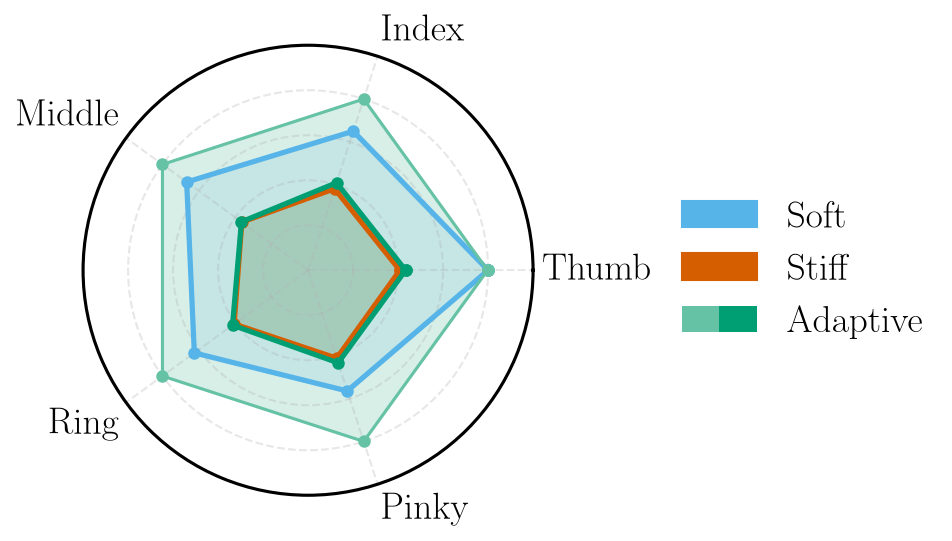

In [105]:
traces = []
for panel in COND_PANELS:
    df_dg = dfs_dg.get(panel['cond'])
    means = []
    for f in FINGERTIPS:
        if df_dg is None or df_dg.empty:
            means.append(0.0); continue
        rows = panel['sel'](df_dg)
        if rows.empty:
            means.append(0.0); continue
        means.append(float((np.sqrt(rows[f'disp_{f}_x_m']**2 + rows[f'disp_{f}_y_m']**2 + rows[f'disp_{f}_z_m']**2) * 1e3).mean()))
    is_adap_before = (panel['cond'] == 'adaptive' and
                      panel['label'].endswith('(before)'))
    traces.append({
        'label':  '' if is_adap_before else
                  ('Adaptive' if panel['cond'] == 'adaptive' else panel['label']),
        'values': means,
        'color':  panel['color'],
        'lw':     1.5 if is_adap_before else 2.5,
        'alpha':  0.25 if is_adap_before else 0.15,
    })

print('Finger spring lengths (mm):')
fig = plt.figure(figsize=RADAR_FIGSIZE)
_ax = fig.add_axes(RADAR_AXES_RECT, projection='polar')
draw_radar([f.capitalize() for f in FINGERTIPS], traces, ax=_ax)
handles = [
    _mpatch.Patch(color=COND_COLORS['soft'],  label='Soft'),
    _mpatch.Patch(color=COND_COLORS['stiff'], label='Stiff'),
    (_ADAPT_BEFORE_COLOR, _ADAPT_AFTER_COLOR),
]
_ax.legend(handles, ['Soft', 'Stiff', 'Adaptive'],
           handler_map={tuple: _SplitHandler()},
           loc='center left', bbox_to_anchor=RADAR_LEG_BBOX,
           ncol=1, frameon=False,
           fontsize=plt.rcParams.get('axes.labelsize', 18))
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_spring_length_radar.pdf'))
plt.show()


### Contact force magnitude per finger

Tip-force magnitude $|F_\mathrm{tip}|$ averaged over the steady-state window.

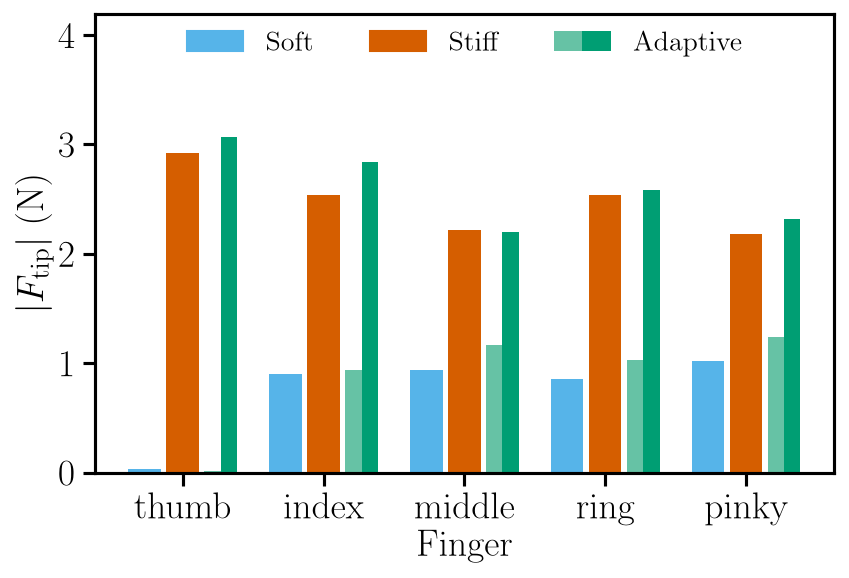

In [106]:
fig, ax = plt.subplots(figsize=BAR_FIGSIZE)
x = np.arange(len(FINGERTIPS))

for i, panel in enumerate(COND_PANELS):
    df_dg = dfs_dg.get(panel['cond'])
    means, stds = [], []
    for f in FINGERTIPS:
        col = f'force_{f}_mag_N'
        if df_dg is None or df_dg.empty or col not in df_dg.columns:
            means.append(0.0); stds.append(0.0); continue
        rows = panel['sel'](df_dg)
        if rows.empty:
            means.append(0.0); stds.append(0.0); continue
        means.append(float(rows[col].mean()))
        stds.append(float(rows[col].std()))
    j       = ['soft', 'stiff', 'adaptive'].index(panel['cond'])
    sub_idx = [p['cond'] for p in COND_PANELS[:i]].count('adaptive')
    if panel['cond'] == 'adaptive':
        offset = _SLOT_W * (j - 1) + _SUB_W * (sub_idx - 0.5)
        w      = _SUB_W
    else:
        offset = _SLOT_W * (j - 1)
        w      = _BAR_W
    ax.bar(x + offset, means, w,
           color=panel['color'], label=panel['label'])

ax.set_xticks(x)
ax.set_xticklabels(FINGERTIPS)
ax.set_xlabel('Finger')
ax.set_ylabel(r'$|F_{\mathrm{tip}}|$ (N)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.30)   # room for the legend above the bars
_dg_legend(ax)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_bar.pdf'), bbox_inches='tight')
plt.show()


Finger contact forces (N):


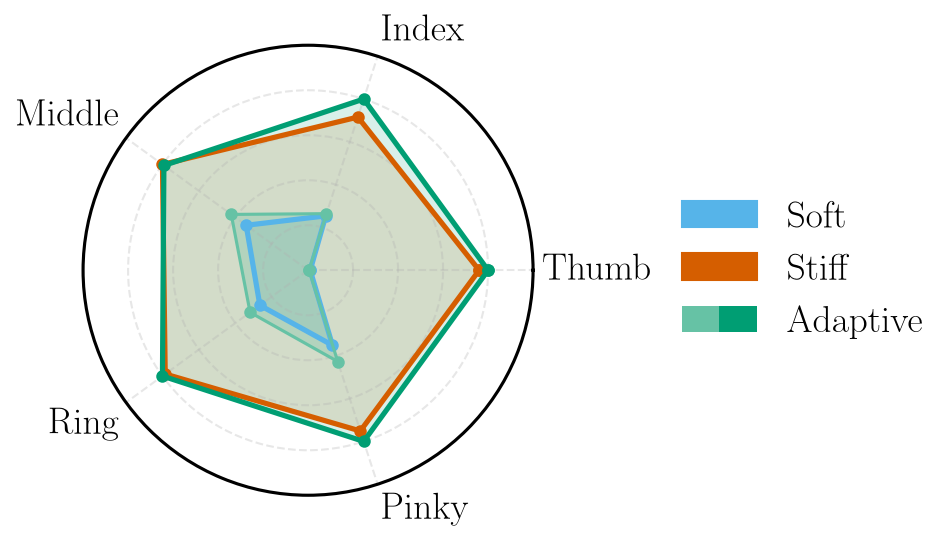

In [107]:
traces = []
for panel in COND_PANELS:
    df_dg = dfs_dg.get(panel['cond'])
    means = []
    for f in FINGERTIPS:
        if df_dg is None or df_dg.empty:
            means.append(0.0); continue
        rows = panel['sel'](df_dg)
        if rows.empty:
            means.append(0.0); continue
        means.append(float((rows[f'force_{f}_mag_N']).mean()))
    is_adap_before = (panel['cond'] == 'adaptive' and
                      panel['label'].endswith('(before)'))
    traces.append({
        'label':  '' if is_adap_before else
                  ('Adaptive' if panel['cond'] == 'adaptive' else panel['label']),
        'values': means,
        'color':  panel['color'],
        'lw':     1.5 if is_adap_before else 2.5,
        'alpha':  0.25 if is_adap_before else 0.15,
    })

print('Finger contact forces (N):')
fig = plt.figure(figsize=RADAR_FIGSIZE)
_ax = fig.add_axes(RADAR_AXES_RECT, projection='polar')
draw_radar([f.capitalize() for f in FINGERTIPS], traces, ax=_ax)
handles = [
    _mpatch.Patch(color=COND_COLORS['soft'],  label='Soft'),
    _mpatch.Patch(color=COND_COLORS['stiff'], label='Stiff'),
    (_ADAPT_BEFORE_COLOR, _ADAPT_AFTER_COLOR),
]
_ax.legend(handles, ['Soft', 'Stiff', 'Adaptive'],
           handler_map={tuple: _SplitHandler()},
           loc='center left', bbox_to_anchor=RADAR_LEG_BBOX,
           ncol=1, frameon=False,
           fontsize=plt.rcParams.get('axes.labelsize', 18))
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_force_radar.pdf'))
plt.show()


### Final hand pose per condition

The motor configuration $q$ at the end of the **Soft**, **Stiff**, and **Adaptive** grasps.

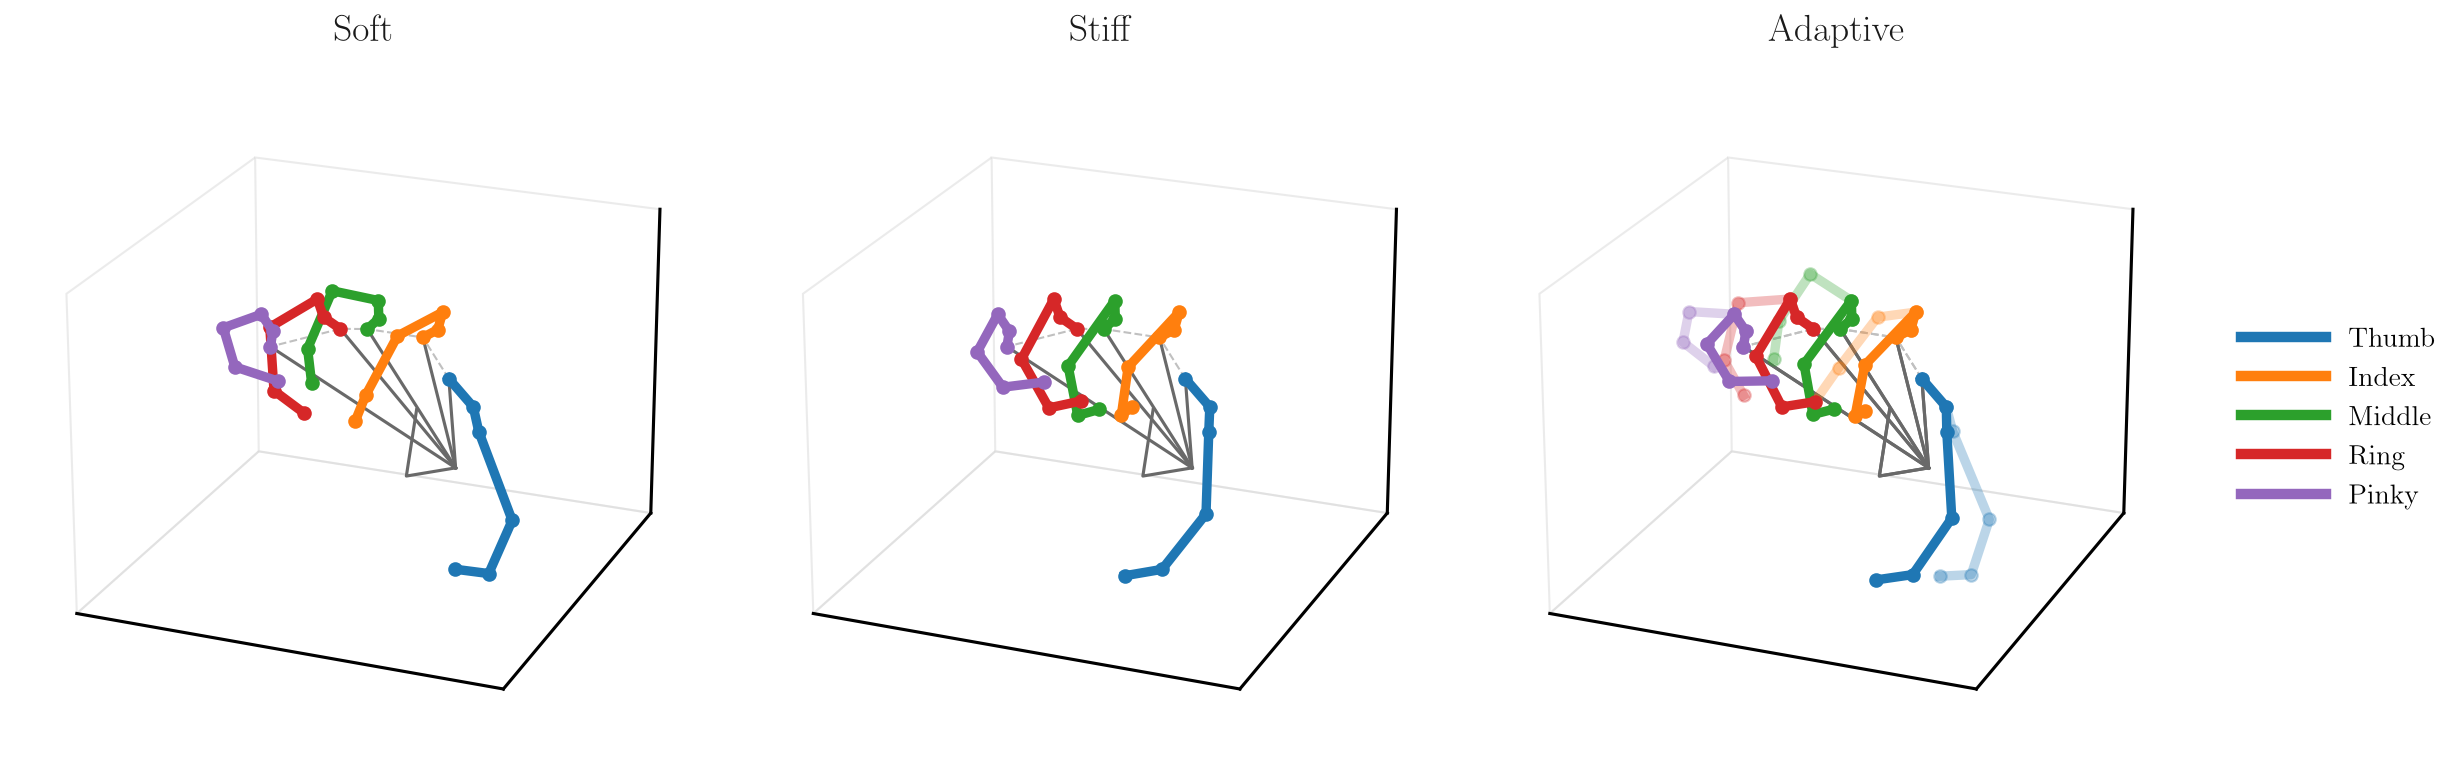

In [108]:
DG_SNAP = [
    ('soft',     'Soft',     lambda d: d[d['phase'] != 'open']),
    ('stiff',    'Stiff',    lambda d: d[d['phase'] != 'open']),
    ('adaptive', 'Adaptive', None),  # handled specially: overlay before + after
]
_Q_COLS_DG = [f'q_{i}' for i in range(13)]
_GHOST_STYLE = {**_STYLE, 'alpha': 0.30}

fig = plt.figure(figsize=(15, 6))
fig.patch.set_facecolor('white')
axes = []
for i, (cond, title, selector) in enumerate(DG_SNAP):
    df_dg = dfs_dg.get(cond)
    if df_dg is None or df_dg.empty:
        continue
    ax = fig.add_subplot(1, len(DG_SNAP), i + 1, projection='3d')
    if cond == 'adaptive':
        # ghost: last frame of soft phase (before stiffening)
        rows_b = df_dg[df_dg['phase'] == 'soft']
        if not rows_b.empty:
            q_b = rows_b[_Q_COLS_DG].iloc[-1].to_numpy(dtype=np.float64)
            plot_hand(q_b, ax=ax, style=_GHOST_STYLE)
        # solid: last frame of closed phase (after stiffening)
        rows_a = df_dg[df_dg['phase'] == 'closed']
        if not rows_a.empty:
            q_a = rows_a[_Q_COLS_DG].iloc[-1].to_numpy(dtype=np.float64)
            plot_hand(q_a, ax=ax, style=_STYLE)
    else:
        rows = selector(df_dg)
        if rows.empty:
            continue
        q = rows[_Q_COLS_DG].iloc[-1].to_numpy(dtype=np.float64)
        plot_hand(q, ax=ax, style=_STYLE)
    for leg in ax.get_legend() and [ax.get_legend()] or []:
        leg.remove()
    _polish_ax(ax, title)
    axes.append(ax)
_sync_axes(axes)
fig.legend(handles=_LEG, loc='center left', ncol=1,
           frameon=False,
           bbox_to_anchor=(1.0, 0.5), handlelength=3.0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_hand_pose.pdf'),
            bbox_inches='tight', dpi=300)
plt.show()


### Stiffness profile over time

$K_t$ commanded to each fingertip as a function of time relative to the close event (dashed line).

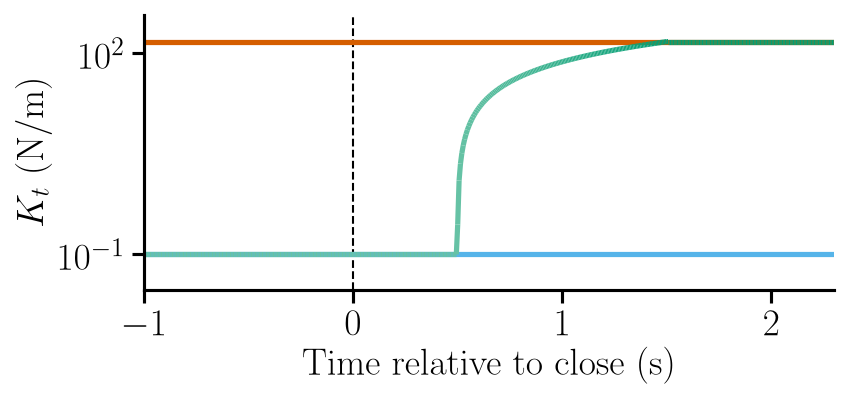

In [119]:
from hand_config import SOFT_DURATION, K_RAMP_DURATION
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors

# ── Tunable layout ────────────────────────────────────────────────────────────
KT_PROFILE_FIG_W  = 10 * 0.6
KT_PROFILE_ASPECT = 5 / 10
T_PRE             = 1.0
T_STEADY          = 0.8

t = np.linspace(-T_PRE, SOFT_DURATION + K_RAMP_DURATION + T_STEADY, 500)

def _k_profile(t_arr, mode):
    if mode == 'soft':
        return np.full_like(t_arr, K_SOFT)
    if mode == 'stiff':
        return np.full_like(t_arr, K_STIFF)
    frac = np.clip((t_arr - SOFT_DURATION) / K_RAMP_DURATION, 0.0, 1.0)
    return K_SOFT + (K_STIFF - K_SOFT) * frac

fig, ax = plt.subplots(figsize=(KT_PROFILE_FIG_W, KT_PROFILE_FIG_W * KT_PROFILE_ASPECT))
ax.set_yscale('log')

ax.axvline(0, color='black', linewidth=1.0, linestyle='--', zorder=1)

# Soft and Stiff: solid single-colour lines
ax.plot(t, _k_profile(t, 'soft'),  color=COND_COLORS['soft'],  linewidth=2.5)
ax.plot(t, _k_profile(t, 'stiff'), color=COND_COLORS['stiff'], linewidth=2.5)

# Adaptive: LineCollection with gradient from before-colour → after-colour
y_adap   = _k_profile(t, 'adaptive')
points   = np.array([t, y_adap]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
c_vals   = np.clip((t[:-1] - SOFT_DURATION) / K_RAMP_DURATION, 0.0, 1.0)
cmap_adap = mcolors.LinearSegmentedColormap.from_list(
    'adap', [_ADAPT_BEFORE_COLOR, _ADAPT_AFTER_COLOR])
lc = LineCollection(segments, cmap=cmap_adap, norm=plt.Normalize(0, 1),
                    linewidth=2.5, zorder=2)
lc.set_array(c_vals)
ax.add_collection(lc)

ax.set_xlabel('Time relative to close (s)')
ax.set_ylabel(r'$K_t$ (N/m)')
ax.set_xlim(-T_PRE, SOFT_DURATION + K_RAMP_DURATION + T_STEADY)
ax.set_ylim(K_SOFT * 0.3, K_STIFF * 2.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_GRASP, 'dynamic_grasp_kt_profile.pdf'), bbox_inches='tight')
plt.show()